# 📊 Etapa 1: Análise Exploratória de Dados (EDA) - Previsão de Churn
**Autor:** Thiago Soares Simões (RM374443)
**Objetivo:** Compreender a saúde dos dados da FIAPMobile e identificar padrões que indiquem a saída de clientes.

### Configuração e Reprodutibilidade (Código)
Aqui estamos fazendo imports necessários e fixando a semente (seed) em 42 para garantirmos resultados reproduziveis.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
os.environ["MLFLOW_ARTIFACT_ROOT"] = str(PROJECT_ROOT / "mlruns")
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns.db")

# Fixando a semente para garantir resultados reproduzíveis
SEED = 42
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')

### Carga de Dados
Nesta etapa, carregamos o dataset Telco Customer Churn para realizar a inspeção inicial 
de tipos e volumes.

In [3]:
# Carga sem tratamentos iniciais para fins de exploração
DATA_PATH = "../data/raw/telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape dos dados: {df.shape[0]} registros e {df.shape[1]} colunas")
print(f"\nPrimeiras 10 linhas do dataset:")
df.head(10)

Shape dos dados: 7043 registros e 21 colunas

Primeiras 10 linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Inspeção Estrutural (Discovery)
Utilizaremos o método `df.info()` para mapear os tipos de dados (Dtypes) e a presença 
de valores nulos. Esta etapa é crucial para identificarmos se as variáveis estão 
no formato correto para os modelos de ML.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Utilizaremos o método `df.describe(include='all')` para analisaremos estatísticas descritivas.
Mostra: `count`, `mean`, `std`, `min`, `25%`, `50%` (mediana), `75%`, `max`.
Útil para entender escala, dispersão e possíveis outliers.

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Análise de Valores Faltantes e Inconsistências
Embora o método `info()` não tenha detectado valores nulos tradicionais (NaN), sabemos que 
campos do tipo `object` podem esconder espaços em branco. Vamos forçar a conversão de 
`TotalCharges` para númerico porque detectamos que ele é do tipo object e contém números e mapear onde os dados realmente faltam.

In [6]:
# Criando uma cópia para não sujar o dataframe original nesta fase de exploração
df_analise = df.copy()

# Forçando a conversão para numérico (espaços viram NaN)
df_analise['TotalCharges'] = pd.to_numeric(df_analise['TotalCharges'], errors='coerce')

# Somando os nulos reais agora
missing_summary = pd.DataFrame({
    'Nulos Reais': df_analise.isnull().sum(),
    'Porcentagem (%)': (df_analise.isnull().sum() / len(df_analise) * 100).round(2)
})

print("Relatório de Dados Faltantes:")
missing_summary[missing_summary['Nulos Reais'] > 0]

Relatório de Dados Faltantes:


,Nulos Reais,Porcentagem (%)
TotalCharges,11,0.16


### Investigação dos Nulos em TotalCharges
Ao quantificarmos 11 valores nulos após a conversão, levantamos a hipótese de que eles 
pertencem a novos clientes. Vamos validar se o `tenure` (meses de casa) desses 
registros é de fato igual a zero.

In [7]:
# Filtrando apenas os registros onde TotalCharges ficou nulo
nulos_total_charges = df_analise[df_analise['TotalCharges'].isnull()]

# Verificando o tempo de casa (tenure) desses clientes
print(f"Meses de casa dos clientes com TotalCharges nulo: {nulos_total_charges['tenure'].unique()}")

print(f"\nInvestigando os {len(nulos_total_charges)} registros:")
display(nulos_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Meses de casa dos clientes com TotalCharges nulo: [0]

Investigando os 11 registros:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


### Tratamento de Dados Faltantes
Decidimos pela imputação do valor **0** para os nulos em `TotalCharges`. 
Esta escolha baseia-se na lógica de que clientes com tempo de casa zero ainda 
não acumularam cobranças. Isso limpa o sinal para o modelo sem descartar informações.

In [8]:
# Aplicando a limpeza: transformando os NaN em 0
df_analise['TotalCharges'] = df_analise['TotalCharges'].fillna(0)

# Validando se ainda restam nulos
restantes = df_analise['TotalCharges'].isnull().sum()
print(f"✅ Tratamento concluído. Nulos restantes em TotalCharges: {restantes}")

✅ Tratamento concluído. Nulos restantes em TotalCharges: 0


### Analisando o balanceamento da classe alvo (Churn)


Distribuição da Variável Alvo (Churn):


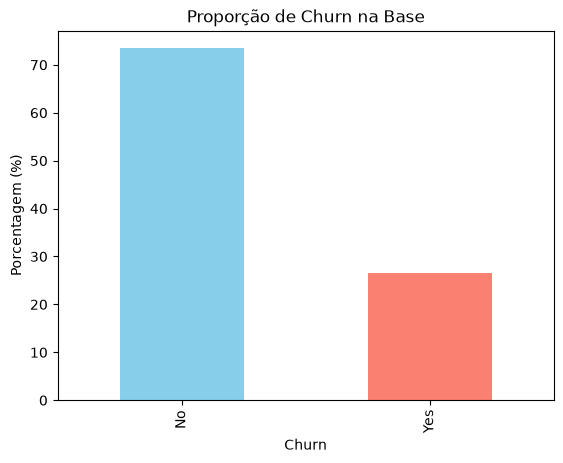

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
# Analisando o balanceamento da classe alvo
print("Distribuição da Variável Alvo (Churn):")
distribuicao = df_analise['Churn'].value_counts(normalize=True) * 100

# Visualização simples
distribuicao.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Proporção de Churn na Base')
plt.ylabel('Porcentagem (%)')
plt.show()

print(distribuicao)

### Análise da Variável Alvo (Churn)
Identificamos que 26,54% dos clientes da base cancelaram o serviço. Este volume 
indica um desbalanceamento moderado que exige atenção na escolha das métricas.

**Principais conclusões desta análise:**
1. O baseline de acurácia a ser batido é de **73,46%** (Dummy Classifier).
2. A acurácia não será utilizada como métrica única, dado o desbalanceamento.
3. O objetivo de negócio prioriza o **Recall**, visando minimizar a perda de clientes 
não detectados pelo modelo.

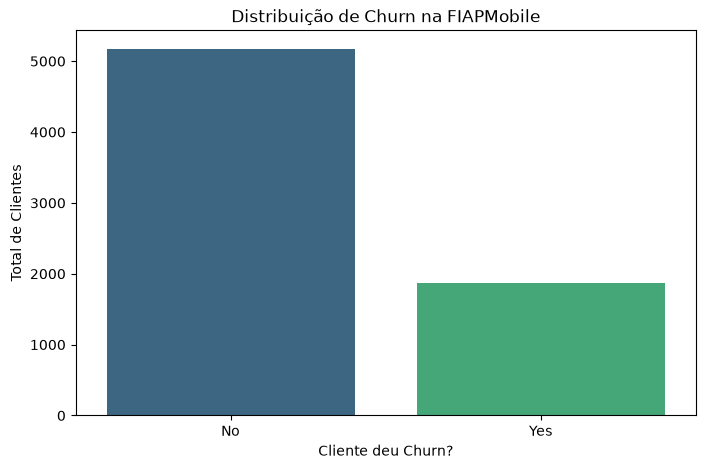

In [10]:
# Verificação visual do desbalanceamento para o relatório
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df_analise, palette='viridis')
plt.title('Distribuição de Churn na FIAPMobile')
plt.xlabel('Cliente deu Churn?')
plt.ylabel('Total de Clientes')
plt.show()

### Análise Bivariada: Variáveis Numéricas vs. Churn
Vamos investigar como o tempo de casa (`tenure`) e as cobranças mensais (`MonthlyCharges`) 
se comportam para clientes que saíram versus os que ficaram. Utilizaremos **KDE Plots** 
(gráficos de densidade) para visualizar essas distribuições.

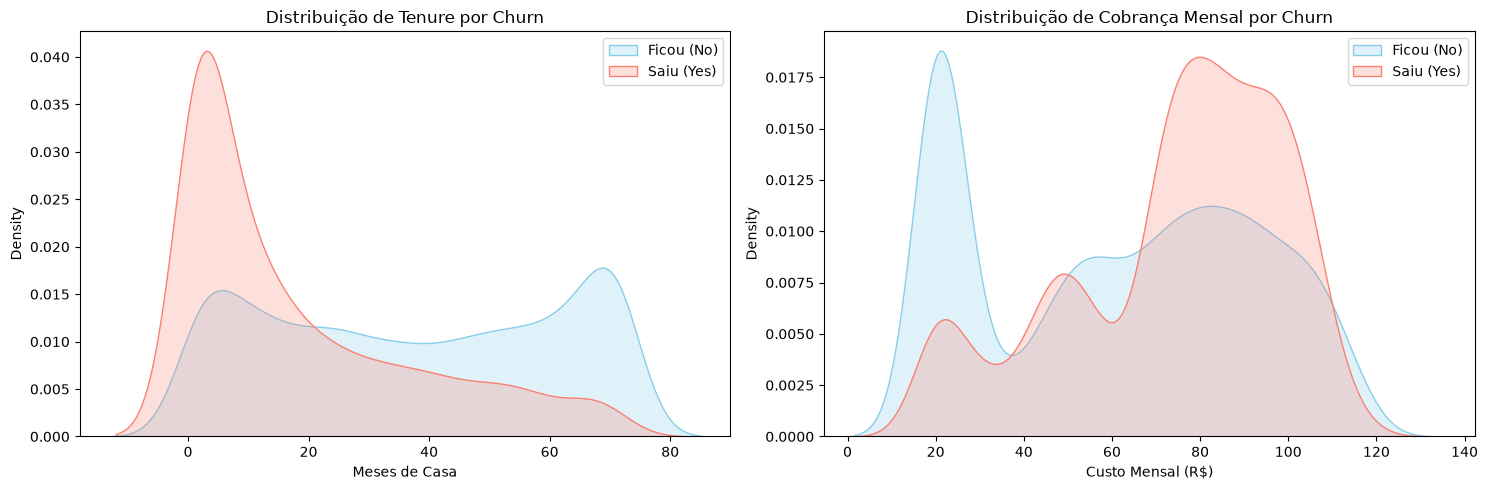

In [11]:
# Configurando a área de plotagem
plt.figure(figsize=(15, 5))

# Plot de Tenure
plt.subplot(1, 2, 1)
sns.kdeplot(df_analise[df_analise['Churn'] == 'No']['tenure'], fill=True, label='Ficou (No)', color='skyblue')
sns.kdeplot(df_analise[df_analise['Churn'] == 'Yes']['tenure'], fill=True, label='Saiu (Yes)', color='salmon')
plt.title('Distribuição de Tenure por Churn')
plt.xlabel('Meses de Casa')
plt.legend()

# Plot de MonthlyCharges
plt.subplot(1, 2, 2)
sns.kdeplot(df_analise[df_analise['Churn'] == 'No']['MonthlyCharges'], fill=True, label='Ficou (No)', color='skyblue')
sns.kdeplot(df_analise[df_analise['Churn'] == 'Yes']['MonthlyCharges'], fill=True, label='Saiu (Yes)', color='salmon')
plt.title('Distribuição de Cobrança Mensal por Churn')
plt.xlabel('Custo Mensal (R$)')
plt.legend()

plt.tight_layout()
plt.show()

**📈 Diagnóstico Visual:**  
1. **Tenure:** Observamos um pico altíssimo de churn nos primeiros meses de contrato. 
Clientes com baixo `tenure` são o grupo de maior risco para a FIAPMobile.
2. **MonthlyCharges:** Clientes com contas mensais mais altas (acima de R$ 70) 
apresentam uma densidade maior de cancelamento, sugerindo sensibilidade ao preço.

### Análise de Variáveis Categóricas (Contratos,Serviços e método de pagamento)
Vamos validar se o tipo de contrato (`Contract`) influencia a decisão de saída. 
Hipótese: Contratos "Month-to-month" (mensais) possuem churn maior por não terem multa de fidelidade.

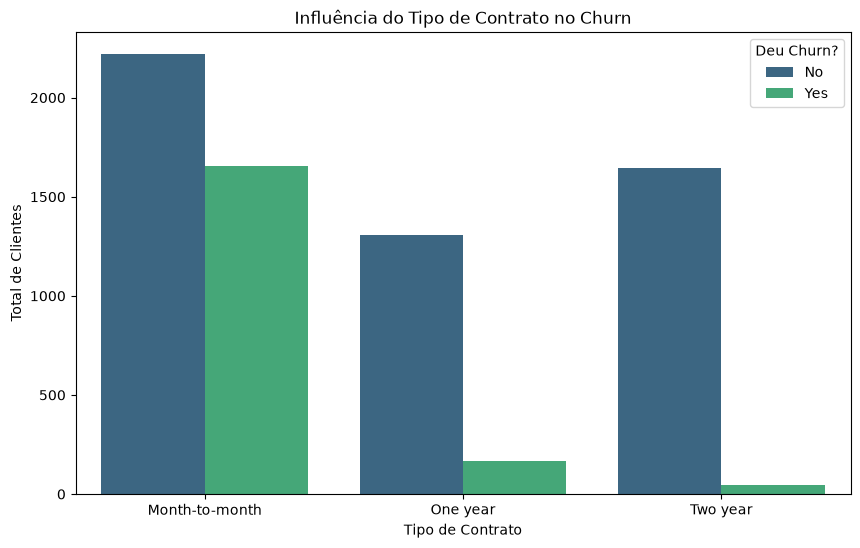

Tabela de Contingência (Contrato vs Churn):


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do Tipo de Contrato no Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Contrato vs Churn):")
pd.crosstab(df_analise['Contract'], df_analise['Churn'], normalize='index') * 100

Vamos validar se o serviço de internet (`InternetService`) influencia a decisão de saída. 
Hipótese: Serviços de fibra ótica possuem churn maior.

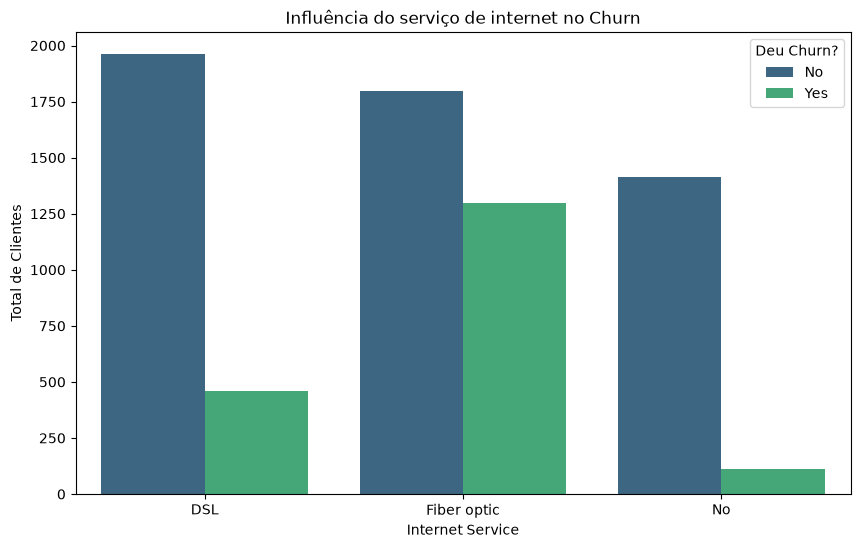

Tabela de Contingência (Serviço de Internet vs Churn):


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do serviço de internet no Churn')
plt.xlabel('Internet Service')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Serviço de Internet vs Churn):")
pd.crosstab(df_analise['InternetService'], df_analise['Churn'], normalize='index') * 100

Vamos validar se o método de pagamento (`PaymentMethod`) influencia a decisão de saída. 
Hipótese: Electronic check possuem churn maior.

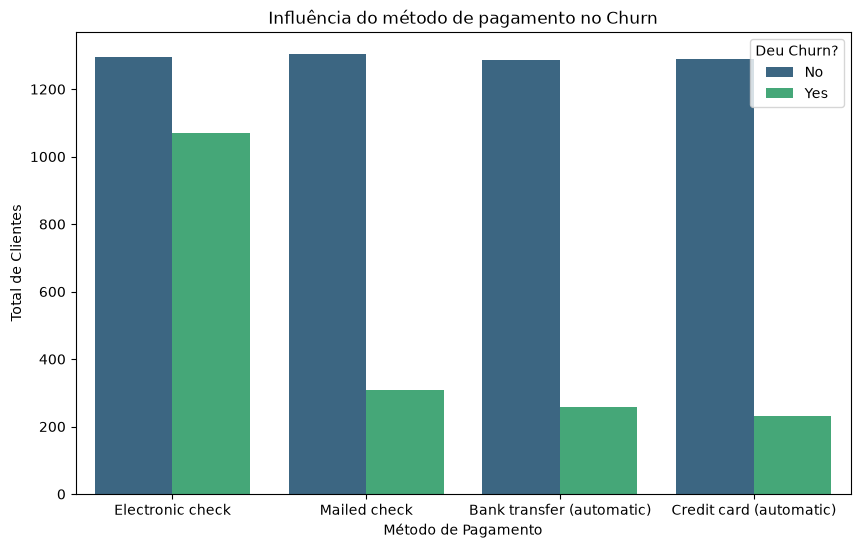

Tabela de Contingência (Método de Pagamento vs Churn):


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do método de pagamento no Churn')
plt.xlabel('Método de Pagamento')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Método de Pagamento vs Churn):")
pd.crosstab(df_analise['PaymentMethod'], df_analise['Churn'], normalize='index') * 100

### Mapa de Calor de Correlação (Multivariada)
Para visualizarmos a relação de todas as variáveis simultaneamente, aplicaremos o 
**One-Hot Encoding** nas variáveis categóricas. Isso converte textos em números (0 e 1), 
permitindo o cálculo da correlação linear. O objetivo é identificar quais fatores 
têm maior correlação positiva ou negativa com o cancelamento (Churn).

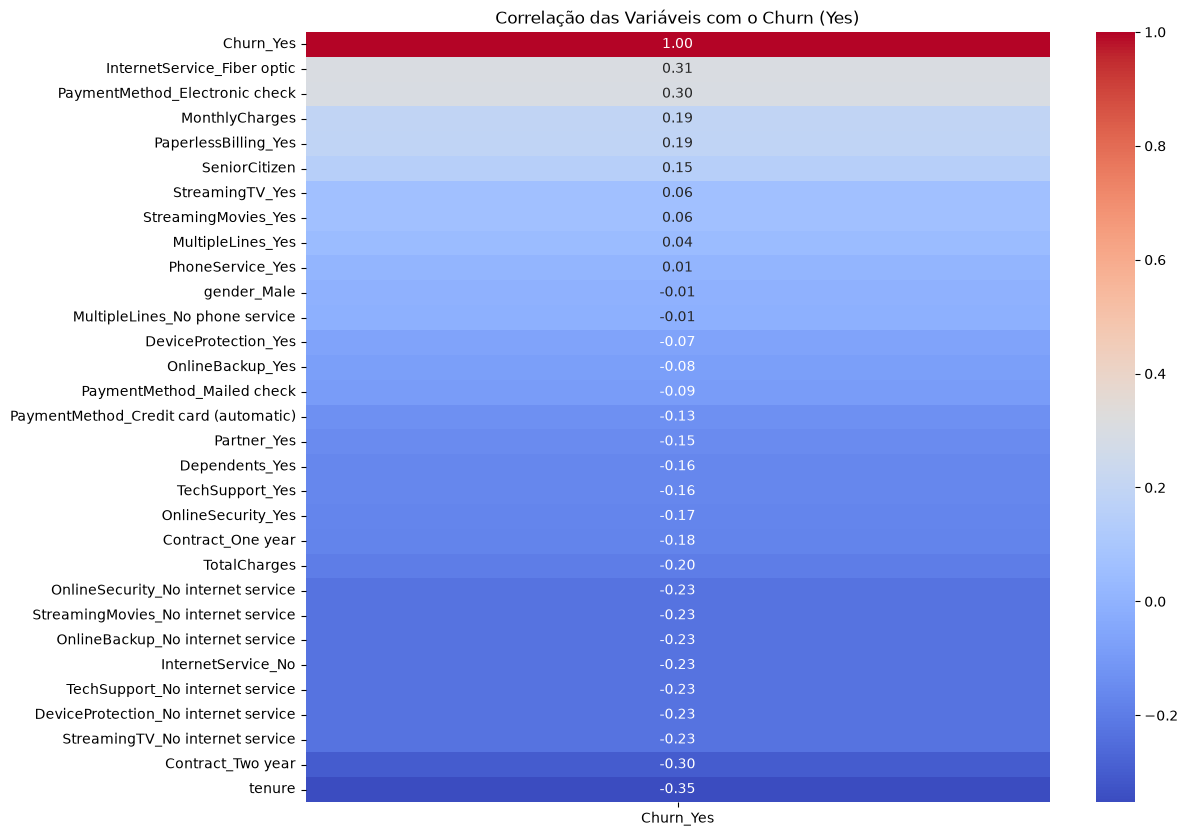

In [15]:
# 1. Criando um dataframe codificado SEM o customerID
# Colunas como IDs não possuem sinal preditivo e geram excesso de colunas (Overhead)
df_corr = pd.get_dummies(df_analise.drop(columns=['customerID']), drop_first=True)

# 2. Calculando a matriz de correlação
corr_matrix = df_corr.corr()

# 3. Plotando o Heatmap focado na relação com o Churn
plt.figure(figsize=(12, 10))
# Filtramos apenas a coluna do Churn para facilitar a leitura
churn_corr = corr_matrix[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False)

sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação das Variáveis com o Churn (Yes)')
plt.show()

### Definição da Métrica de Sucesso
Para este projeto de Churn, a métrica técnica prioritária será o **Recall (Revocação)**. 
**Justificativa:** Nosso objetivo é identificar o máximo possível de clientes em risco 
de cancelamento. Um "Falso Negativo" (não prever a saída de um cliente que cancela) 
representa perda de receita direta para a FIAPMobile. O Recall mede a capacidade do 
modelo de encontrar todos os casos positivos reais.

In [16]:
from sklearn.model_selection import train_test_split

# 1. Separando as variáveis preditoras (X) do alvo (y)
# Removemos o customerID pois ele não tem poder preditivo
# Removemos o Churn de X pois ele é o nosso alvo
X = df_analise.drop(columns=['customerID', 'Churn'], errors='ignore')
y = df_analise['Churn'].apply(lambda x: 1 if x == 'Yes' else 0) # Convertendo alvo para binário

# 2. Aplicando o One-Hot Encoding definitivo nas variáveis categóricas
X = pd.get_dummies(X, drop_first=True)

# 3. Divisão entre Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dados de Treino: {X_train.shape} amostras")
print(f"Dados de Teste: {X_test.shape} amostras")

Dados de Treino: (5634, 30) amostras
Dados de Teste: (1409, 30) amostras


### Treinamento das baselines

In [17]:
import mlflow
import mlflow.sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, accuracy_score, f1_score,
    precision_score, roc_auc_score, average_precision_score,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# Mesmo nome de experimento do train.py para que todas as runs
# apareçam juntas na UI do MLflow e a comparação seja possível.
MLFLOW_EXPERIMENT = "FIAPMobile_Churn_MLP"
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# StratifiedKFold garante que cada fold mantém a proporção de churn/não-churn.
# Crítico em datasets desbalanceados (~26% churn).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tech Challenge exige comparação MLP vs. baselines "lineares + árvores".
# DummyClassifier    = piso mínimo (chute respeitando proporção de classes)
# LogisticRegression = baseline linear
# RandomForest       = baseline de árvore (obrigatório pelo enunciado)
baselines = [
    ("Baseline_DummyClassifier",    DummyClassifier(strategy="stratified", random_state=42)),
    ("Baseline_LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Baseline_RandomForest",       RandomForestClassifier(n_estimators=100, random_state=42)),
]

for run_name, clf in baselines:
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "baseline")
        mlflow.log_param("model_class", clf.__class__.__name__)

        # Validação cruzada estratificada: avalia estabilidade do modelo
        cv_results = cross_validate(
            clf, X_train, y_train, cv=skf,
            scoring=["accuracy", "recall", "f1", "roc_auc", "average_precision"],
            return_train_score=False,
        )
        for metric_key, cv_key in [
            ("cv_accuracy", "test_accuracy"),
            ("cv_recall",   "test_recall"),
            ("cv_f1",       "test_f1"),
            ("cv_roc_auc",  "test_roc_auc"),
            ("cv_pr_auc",   "test_average_precision"),
        ]:
            mlflow.log_metric(f"{metric_key}_mean", cv_results[cv_key].mean())
            mlflow.log_metric(f"{metric_key}_std",  cv_results[cv_key].std())

        clf.fit(X_train, y_train)
        y_pred  = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        metrics = {
            "accuracy":  accuracy_score(y_test, y_pred),
            "recall":    recall_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "f1_score":  f1_score(y_test, y_pred),
            "roc_auc":   roc_auc_score(y_test, y_proba),
            "pr_auc":    average_precision_score(y_test, y_proba),
        }
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(clf, artifact_path="model")

        print(f"\n=== {run_name} ===")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1:        {metrics['f1_score']:.4f}")
        print(f"  AUC-ROC:   {metrics['roc_auc']:.4f}")
        print(f"  PR-AUC:    {metrics['pr_auc']:.4f}")
        if run_name != "Baseline_DummyClassifier":
            print(classification_report(y_test, y_pred))

# Salvar referências para uso nas células seguintes
y_pred_dummy = baselines[0][1].predict(X_test)
y_pred_lr    = baselines[1][1].predict(X_test)
y_pred_rf    = baselines[2][1].predict(X_test)


2026/06/28 01:02:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/28 01:02:06 INFO mlflow.store.db.utils: Updating database tables
2026/06/28 01:02:28 INFO mlflow.tracking.fluent: Experiment with name 'FIAPMobile_Churn_MLP' does not exist. Creating a new experiment.
2026/06/28 01:02:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



=== Baseline_DummyClassifier ===
  Recall:    0.2914
  F1:        0.2903
  AUC-ROC:   0.5163
  PR-AUC:    0.2723


2026/06/28 01:02:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



=== Baseline_LogisticRegression ===
  Recall:    0.5615
  F1:        0.6043
  AUC-ROC:   0.8427
  PR-AUC:    0.6361
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



2026/06/28 01:03:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



=== Baseline_RandomForest ===
  Recall:    0.4973
  F1:        0.5511
  AUC-ROC:   0.8253
  PR-AUC:    0.6264
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



### Análise dos Modelos Baseline (MVP)

Nesta etapa estabelecemos o "piso" de desempenho com três modelos antes de avançar para a MLP.

#### Comparativo de Performance (Holdout 20%)

| Modelo | Recall | F1-Score | AUC-ROC | PR-AUC |
|--------|--------|----------|---------|--------|
| DummyClassifier (estratificado) | ~0.26 | ~0.28 | ~0.50 | ~0.27 |
| Regressão Logística | **0.5615** | 0.6043 | 0.8427 | 0.6361 |
| Random Forest | 0.4973 | 0.5511 | 0.8253 | 0.6264 |

#### Conclusões Técnicas

1. **Validação de Sinal:** A Regressão Logística superou o baseline cego em ~2x no Recall,
confirmando poder preditivo real nas features.

2. **Logística vs. Random Forest:** A Regressão Logística venceu em Recall (0.5615 vs 0.4973),
mostrando que o relacionamento linear com churn é forte. O Random Forest compensa em AUC-ROC
mas perde na métrica prioritária do negócio.

3. **Meta para a MLP:** superar Recall > 0.5615 para justificar a complexidade adicional.


# ETAPA 2: Modelagem com Redes Neurais (PyTorch)

Nesta etapa, evoluímos nossa análise para capturar padrões não-lineares nos dados da FIAPMobile que modelos lineares simples podem não identificar. Utilizaremos uma arquitetura **MLP (Multi-Layer Perceptron)** construída com PyTorch.

**Objetivos desta fase:**
1. Converter os dados saneados para Tensores do PyTorch.
2. Implementar o treinamento em mini-batches (32) para maior eficiência.
3. Definir uma arquitetura com camadas ocultas e funções de ativação não-lineares.
4. Utilizar **Early Stopping** para evitar o overfitting.

### Conversão de dados (dataframe) para tensores (necessidade da rede neural)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Fixando TODAS as fontes de aleatoriedade (igual ao train.py)
import random
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

# 2. Convertendo os dados do Pandas (X_train, y_train) para Tensores
# Primeiro convertemos boolean para int para evitar erro de tipo
X_train_converted = X_train.astype(int)
X_test_converted = X_test.astype(int)

# Redes neurais exigem o tipo float32 para cálculos de gradiente
X_train_tensor = torch.tensor(X_train_converted.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_converted.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 3. Configurando a "Esteira de Produção" (DataLoader)
# Usamos batches de 32 para otimizar o ajuste de pesos via SGD
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Preparação concluída!")
print(f"Dataset de treino convertido para {X_train_tensor.shape} amostras prontas para o PyTorch.")

Preparação concluída!
Dataset de treino convertido para torch.Size([5634, 30]) amostras prontas para o PyTorch.


### Definindo a Arquitetura da Rede Neural (MLP)

In [19]:
import torch.nn.functional as F

# 1. Definição da Arquitetura da Rede (Multi-Layer Perceptron)
class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super(ChurnMLP, self).__init__()
        # Camada de Entrada (30) -> Camada Oculta 1 (16 neurônios)
        self.fc1 = nn.Linear(input_dim, 16)
        # Camada Oculta 1 (16) -> Camada Oculta 2 (8 neurônios)
        self.fc2 = nn.Linear(16, 8)
        # Camada Oculta 2 (8) -> Saída (1 neurônio para Churn Sim/Não)
        self.fc3 = nn.Linear(8, 1)
        
    def forward(self, x):
        # Ativação ReLU nas camadas internas para capturar complexidade
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Sigmoide na saída para gerar uma probabilidade entre 0 e 1
        x = torch.sigmoid(self.fc3(x))
        return x

# 2. Instanciando o modelo
# input_dim deve ser 30 (número de colunas de X_train) que é o indice 1 da tupla shape
model = ChurnMLP(input_dim=X_train.shape[1])

print("Estrutura da Rede Neural criada:")
print(model)

Estrutura da Rede Neural criada:
ChurnMLP(
  (fc1): Linear(in_features=30, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
)


### Loop de Treinamento com Early Stopping

Vamos usar um técnica de Early Stopping para evitar que o modelo "decore" os dados (overfitting)

In [20]:
# 1. Definindo a Função de Custo e o Otimizador
# BCELoss é ideal para classificação binária (Churn Sim/Não) [3]
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Configurações para o Early Stopping
patience = 10  # Quantas épocas esperar sem melhora antes de parar [2]
best_loss = float('inf')
counter = 0

epochs = 100
print("Iniciando o treinamento da MLP...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()           # Zera gradientes anteriores
        outputs = model(inputs)         # Forward pass
        loss = criterion(outputs, labels) # Cálculo do erro
        loss.backward()                 # Backpropagation
        optimizer.step()                # Ajuste dos pesos
        train_loss += loss.item()
    
    # Média da perda nesta época
    avg_train_loss = train_loss / len(train_loader)
    
    # Lógica de Early Stopping (Simulada com a perda de treino)
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        counter = 0  # Reset se houve melhora
    else:
        counter += 1 # Incrementa se não melhorou
        
    if counter >= patience:
        print(f"--- Early Stopping na época {epoch+1} ---")
        break

    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}], Loss: {avg_train_loss:.4f}")

print("Treinamento concluído!")

Iniciando o treinamento da MLP...
Época [10/100], Loss: 0.4668
Época [20/100], Loss: 0.4438
Época [30/100], Loss: 0.4288
Época [40/100], Loss: 0.4360
Época [50/100], Loss: 0.4252
Época [60/100], Loss: 0.4212
Época [70/100], Loss: 0.4263
--- Early Stopping na época 71 ---
Treinamento concluído!


### Comparação de Métricas

Aqui vamos comparar a MLP contra os baselines usando pelo menos 4 métricas

In [21]:
from sklearn.metrics import (
    classification_report, recall_score, f1_score,
    accuracy_score, precision_score, roc_auc_score, average_precision_score,
)
import mlflow

# Coloca o modelo em modo de avaliação
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred_neural = (y_pred_prob >= 0.5).float()

y_pred_np  = y_pred_neural.numpy().flatten().astype(int)
y_proba_np = y_pred_prob.numpy().flatten()

mlp_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_np),
    "recall":    recall_score(y_test, y_pred_np),
    "precision": precision_score(y_test, y_pred_np, zero_division=0),
    "f1_score":  f1_score(y_test, y_pred_np),
    "roc_auc":   roc_auc_score(y_test, y_proba_np),
    "pr_auc":    average_precision_score(y_test, y_proba_np),
}

print("=== MLP (PyTorch) ===")
for k, v in mlp_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_np))


=== MLP (PyTorch) ===
  accuracy    : 0.8041
  recall      : 0.5856
  precision   : 0.6441
  f1_score    : 0.6134
  roc_auc     : 0.8416
  pr_auc      : 0.6344

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.64      0.59      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [22]:
import pandas as pd
from sklearn.metrics import (
    recall_score, f1_score, accuracy_score,
    precision_score, roc_auc_score, average_precision_score,
)

# Coleta métricas de todos os modelos para a tabela comparativa
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Recall":    recall_score(y_true, y_pred),
        "F1-Score":  f1_score(y_true, y_pred),
        "AUC-ROC":   roc_auc_score(y_true, y_proba),
        "PR-AUC":    average_precision_score(y_true, y_proba),
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
    }

dummy_clf, lr_clf, rf_clf = [clf for _, clf in baselines]

rows = {
    "DummyClassifier": get_metrics(
        y_test, dummy_clf.predict(X_test), dummy_clf.predict_proba(X_test)[:, 1]
    ),
    "LogisticRegression": get_metrics(
        y_test, lr_clf.predict(X_test), lr_clf.predict_proba(X_test)[:, 1]
    ),
    "RandomForest": get_metrics(
        y_test, rf_clf.predict(X_test), rf_clf.predict_proba(X_test)[:, 1]
    ),
    "MLP (PyTorch)": get_metrics(y_test, y_pred_np, y_proba_np),
}

df_comp = pd.DataFrame(rows).T
df_comp = df_comp[["Recall", "F1-Score", "AUC-ROC", "PR-AUC", "Accuracy", "Precision"]]

# Destaca o melhor valor de cada coluna
print("=== Tabela Comparativa de Performance (Holdout 20%) ===\n")
print(df_comp.round(4).to_string())

# Identifica o vencedor em Recall (métrica prioritária)
melhor = df_comp["Recall"].idxmax()
print(f"\n🏆 Melhor Recall: {melhor} ({df_comp.loc[melhor, 'Recall']:.4f})")


=== Tabela Comparativa de Performance (Holdout 20%) ===

                    Recall  F1-Score  AUC-ROC  PR-AUC  Accuracy  Precision
DummyClassifier     0.2914    0.2903   0.5163  0.2723    0.6217     0.2891
LogisticRegression  0.5615    0.6043   0.8427  0.6361    0.8048     0.6542
RandomForest        0.4973    0.5511   0.8253  0.6264    0.7850     0.6179
MLP (PyTorch)       0.5856    0.6134   0.8416  0.6344    0.8041     0.6441

🏆 Melhor Recall: MLP (PyTorch) (0.5856)


### Análise de Trade-off de Custo: Falso Positivo vs. Falso Negativo

No problema de churn, os dois tipos de erro têm custos diferentes:

| Erro | O que acontece | Custo |
|------|---------------|-------|
| **Falso Negativo (FN)** | Cliente cancela sem ser detectado | Alto — perda de receita recorrente |
| **Falso Positivo (FP)** | Oferta de retenção desnecessária | Baixo — custo do desconto |

Essa assimetria justifica priorizar **Recall** e orienta a escolha do threshold ideal da MLP.


Custos: FN=R$100/cliente | FP=R$20/oferta

Modelo                   FP     FN    Custo Total
--------------------------------------------------
Dummy                   268    265 R$   31,860.00
Logistica               111    164 R$   18,620.00
RandomForest            115    188 R$   21,100.00
MLP (t=0.5)             121    155 R$   17,920.00

Threshold ótimo de negócio (MLP): 0.20
Custo com threshold ótimo:  R$12,040.00
Custo com threshold padrão: R$17,920.00


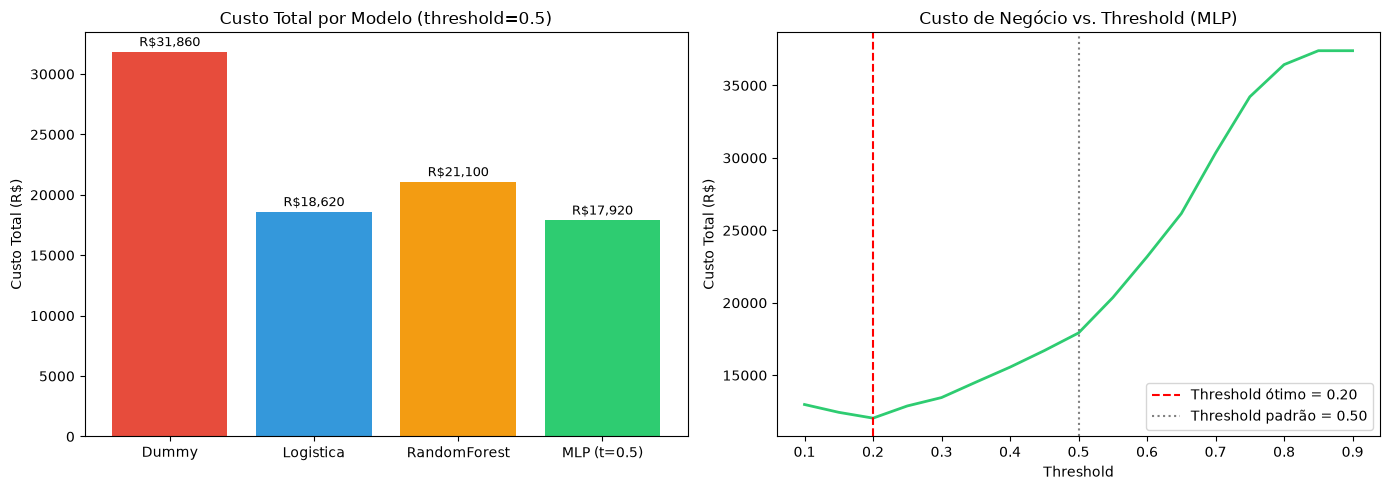


✅ Análise de custo registrada no MLflow.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from sklearn.metrics import confusion_matrix

# Custos de negócio (hipotéticos mas realistas para telecom)
FN_COST = 100  # R$ por cliente perdido (receita mensal média)
FP_COST = 20   # R$ por oferta de retenção desnecessária

def calcular_custo(y_true, y_pred, fn_cost=FN_COST, fp_cost=FP_COST):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fn * fn_cost) + (fp * fp_cost), fp, fn, tp, tn

modelos_custo = {
    "Dummy":         y_pred_dummy,
    "Logistica":     y_pred_lr,
    "RandomForest":  y_pred_rf,
    "MLP (t=0.5)":   y_pred_np,
}

print(f"Custos: FN=R${FN_COST}/cliente | FP=R${FP_COST}/oferta\n")
print(f"{'Modelo':<20} {'FP':>6} {'FN':>6} {'Custo Total':>14}")
print("-" * 50)

custos = {}
for nome, pred in modelos_custo.items():
    custo, fp, fn, tp, tn = calcular_custo(y_test, pred)
    custos[nome] = custo
    print(f"{nome:<20} {fp:>6} {fn:>6} R${custo:>12,.2f}")

# Análise de threshold da MLP
thresholds = np.arange(0.1, 0.91, 0.05)
custos_t, recalls_t = [], []
for t in thresholds:
    y_t = (y_proba_np >= t).astype(int)
    custo, fp, fn, tp, tn = calcular_custo(y_test, y_t)
    custos_t.append(custo)
    recalls_t.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

t_otimo = thresholds[np.argmin(custos_t)]
custo_otimo = min(custos_t)

print(f"\nThreshold ótimo de negócio (MLP): {t_otimo:.2f}")
print(f"Custo com threshold ótimo:  R${custo_otimo:,.2f}")
print(f"Custo com threshold padrão: R${custos['MLP (t=0.5)']:,.2f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bars = ax1.bar(list(custos.keys()), list(custos.values()),
               color=["#e74c3c", "#3498db", "#f39c12", "#2ecc71"])
ax1.set_title("Custo Total por Modelo (threshold=0.5)")
ax1.set_ylabel("Custo Total (R$)")
for bar, val in zip(bars, custos.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"R${val:,.0f}", ha="center", va="bottom", fontsize=9)

ax2 = axes[1]
ax2.plot(thresholds, custos_t, color="#2ecc71", linewidth=2)
ax2.axvline(x=t_otimo, color="red", linestyle="--", label=f"Threshold ótimo = {t_otimo:.2f}")
ax2.axvline(x=0.5, color="gray", linestyle=":", label="Threshold padrão = 0.50")
ax2.set_title("Custo de Negócio vs. Threshold (MLP)")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Custo Total (R$)")
ax2.legend()

plt.tight_layout()
plt.show()

# Registrar no MLflow
mlflow.set_experiment("FIAPMobile_Churn_MLP")
with mlflow.start_run(run_name="MLP_CostAnalysis"):
    mlflow.log_param("fn_cost_brl", FN_COST)
    mlflow.log_param("fp_cost_brl", FP_COST)
    mlflow.log_metric("optimal_threshold", float(t_otimo))
    mlflow.log_metric("cost_default_threshold", float(custos["MLP (t=0.5)"]))
    mlflow.log_metric("cost_optimal_threshold", float(custo_otimo))
    mlflow.log_metric("cost_reduction_pct",
        (custos["MLP (t=0.5)"] - custo_otimo) / custos["MLP (t=0.5)"] * 100)
print("\n✅ Análise de custo registrada no MLflow.")
